# Notebook de ejemplo de uso de modelo DINOv2 para diversas tareas de VA, Master IA UMU, curso 2025/26

# 🦖 DINOv2: El poder de las características universales

Si tuviéramos que resumir [DINOv2](https://dinov2.metademolab.com/) en una frase sería: **es un traductor universal de imágenes a números**. DINOv2 es una red neuronal que toma cualquier imagen como entrada y la convierte en una representación numérica, un "vector de características".

![Diagrama DINOv2](https://github.com/empb/mnti-via-images/blob/main/diagrama_notebook.png?raw=true)

Este vector captura la esencia semántica de la imagen. Esto significa que imágenes visualmente similares (por ejemplo, dos fotos de dos razas de perro distintas) producirán vectores numéricos muy parecidos entre sí. A su vez, la foto de un perro y la de un coche producirán vectores muy diferentes.

## 0. Preparación del notebook

**Imports necesarios**

In [1]:
import os
import glob
import time

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

import torch
from torchvision import transforms
from transformers import AutoImageProcessor, DPTForDepthEstimation

**Carga del dataset**

Vamos a utilizar un *dataset* de [Perros vs Gatos](https://www.kaggle.com/competitions/dogs-vs-cats) de una competición de Kaggle. Este consiste en 25.000 imágenes de perros y gatos (12.500 de cada clase). Microsoft tiene también una [versión descargable](https://www.microsoft.com/en-us/download/details.aspx?id=54765) de este, así que para no tener que crearnos una cuenta de Kaggle, lo descargamos directamente de ahí.

In [2]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
!unzip -qn kagglecatsanddogs_5340.zip

--2025-10-02 08:21:46--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.0.166.52, 2600:1409:9800:158d::317f, 2600:1409:9800:1583::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.0.166.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip.1’

kagglecatsanddogs_5 100%[===================>] 786.67M   205MB/s    in 4.0s    

2025-10-02 08:21:50 (199 MB/s) - ‘kagglecatsanddogs_5340.zip.1’ saved [824887076/824887076]



Antes de comenzar, vamos a visualizar algunos ejemplos de las imágenes descargadas.

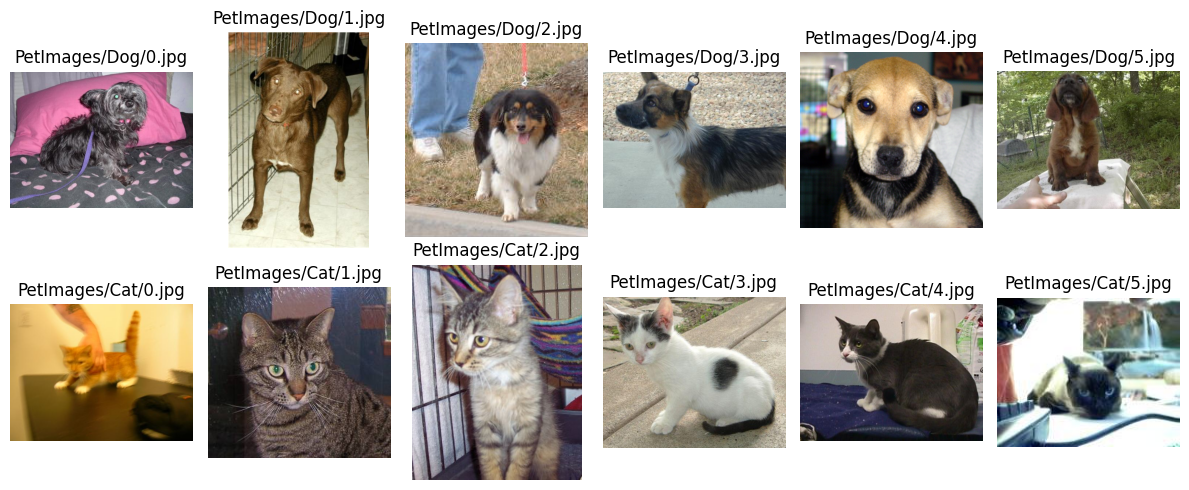

In [3]:
# El dataset se encuentra en la carpeta PetImages, 12500 imágenes en
# cada subcarpeta de "Dog/" y "Cat/". Extraemos las rutas:
DOGS_DIR = "PetImages/Dog"
CATS_DIR = "PetImages/Cat"

dog_paths = sorted(glob.glob(os.path.join(DOGS_DIR, "*.jpg")),
        key=lambda path: int(os.path.basename(path).split('.')[0]))
cat_paths = sorted(glob.glob(os.path.join(CATS_DIR, "*.jpg")),
        key=lambda path: int(os.path.basename(path).split('.')[0]))

# Número de imágenes a mostrar por categoría
num_images = 6

# Usamos matplotlib para mostrar las imágenes:
plt.figure(figsize=(12, 5))
for i, paths in enumerate([dog_paths, cat_paths]):
  for j, path in enumerate(paths[:num_images]):
      image = Image.open(path)
      plt.subplot(2, num_images, num_images*i+j+1)
      plt.title(path)
      plt.imshow(image)
      plt.axis("off")

# Ajustamos y mostramos las imágenes
plt.tight_layout()
plt.show()

## 1. Carga del modelo de DINOv2

Básicamente, lo que hace el siguiente código es poner a punto el modelo de DINOv2. Podemos elegir qué tan "potente" queremos que sea el modelo. Cuanto más grande sea, mayor será su tamaño en memoria a cambio de tener *embeddings* con mayor número de características:

* `small`: Genera embeddings de tamaño `384`.
* `base`: Genera embeddings de tamaño `768`.
* `large`: Genera embeddings de tamaño `1024`.

Si se dispone de tarjeta gráfica compatible, el modelo se cargará en GPU, por lo que la inferencia será muchísimo más rápida. Estamos hablando de una diferencia de entre 1-2s en CPU a 10-20ms en GPU.

In [4]:
# Selecciona el tamaño del modelo:
model_size = "base"  #"small", "base" o "large"

# En dinov2 el tamaño de parche que utiliza el transformer es de 14x14 pixeles
# Esto por ejemplo cambia en DINOv3, donde los parches son de 16x16 pixeles
PATCH_SIZE = 14

model_dict = {
    "small": "dinov2_vits14",
    "base": "dinov2_vitb14",
    "large": "dinov2_vitl14"
}

# Si tenemos CUDA disponible, usamos GPU para correr la inferencia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = model_dict[model_size]
print(f"Cargando modelo '{model_name}' en '{device}'...")

# Cargamos el modelo:
dinov2 = torch.hub.load("facebookresearch/dinov2", model_name)
dinov2.to(device)  # Mueve el modelo a GPU si está disponible
dinov2.eval()      # Poner el modelo en modo de evaluación
print("Modelo cargado correctamente y listo para inferencia.")

Cargando modelo 'dinov2_vitb14' en 'cuda'...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Modelo cargado correctamente y listo para inferencia.


Para no pelearnos con los detalles del preprocesamiento, la siguiente función está pensada para que funcione prácticamente "out of the box". La idea es sencilla: se le pasa la imagen a analizar (junto con el modelo y el dispositivo que ya cargamos antes) y la función devuelve tanto el **token CLS** (que contiene información global de la imagen) como los **tokens de parche** (con la información tanto local como global de cada parche de 14x14 pixeles).

In [5]:
# Realiza inferencia con DINOv2 sobre una imagen.
# Recibe como parámetros: la imagen, el modelo de DINOv2 ya cargado desde
# pytorch y el dispositivo donde se corre la inferencia (cpu/gpu)
def infer_dinov2(image, model, device, patch_size=PATCH_SIZE):
    # Por si la imagen no estuviera en RGB, la convertimos
    if image.mode != "RGB":
        image = image.convert("RGB")

    # Transformamos la imagen para que sus dimensiones sean múltiplos de 14
    w, h = image.size
    new_w = round(w / patch_size) * patch_size
    new_h = round(h / patch_size) * patch_size
    image = image.resize((new_w, new_h), resample=Image.BICUBIC)

    # Preprocesamos la imagen antes de pasarla al modelo de dino
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img_tensor = preprocess(image).unsqueeze(0).to(device)

    # Realizamos la inferencia
    features_dict = model.forward_features(img_tensor)

    # Extraemos los tokens de CLS (token de características global para toda
    # la imagen) y tokens de parches (uno por cada parche de 14x14 píxeles)
    cls_token = features_dict["x_norm_clstoken"].cpu().detach().numpy()
    patch_tokens = features_dict["x_norm_patchtokens"].cpu().detach().numpy()

    # Eliminamos la dimensión redundante
    return cls_token.squeeze(), patch_tokens.squeeze()

### EJEMPLO CON UNA IMAGEN DE UN PERRO ###
image = Image.open(dog_paths[0])
# Realizamos la inferencia sobre la imagen cargada
t0 = time.time()
cls_token, patch_tokens = infer_dinov2(image, dinov2, device)
print(f"¡Inferencia completada en {time.time()-t0:.3f}s!")

w, h = image.size
new_w = round(w / PATCH_SIZE) * PATCH_SIZE
new_h = round(h / PATCH_SIZE) * PATCH_SIZE
w_patch = new_w // PATCH_SIZE
h_patch = new_h // PATCH_SIZE
print(f"Imagen de tamaño {w}x{h} pixeles -> {new_w}x{new_h} pixeles")
print(f"Tamaño de la imagen de parches: {w_patch}x{h_patch} parches = {w_patch*h_patch} parches en total")
print("\n--- SALIDA DEL MODELO ---")
print(f"Forma del Tensor del Token CLS:  {cls_token.shape}")
print(f"Forma del Tensor de Tokens de Parche: {patch_tokens.shape}")

¡Inferencia completada en 0.545s!
Imagen de tamaño 500x375 pixeles -> 504x378 pixeles
Tamaño de la imagen de parches: 36x27 parches = 972 parches en total

--- SALIDA DEL MODELO ---
Forma del Tensor del Token CLS:  (768,)
Forma del Tensor de Tokens de Parche: (972, 768)


## 2. Reducción de características mediante PCA

Cada uno de los parches de nuestras imágenes está descrito por un vector con **768 valores** (el *embedding* del modelo `base`). Intentar entender o visualizar 768 dimensiones es simplemente imposible para un cerebro humano. Para solucionar esto, podemos emplear técnicas de reducción de dimensionalidad. Probaremos con el **Análisis de Componentes Principales (PCA)**. En nuestro caso, incluso con menos características somos capaces de discriminar la forma de los perros (aunque esto no es siempre así).

El proceso es el siguiente:

1.  **Creamos un "espacio de conocimiento"**: Primero, juntamos los *embeddings* de parche de varias imágenes de perros. Con todos ellos, le enseñamos al PCA cuáles son las características más importantes y que más varían en las imágenes de perros.

2.  **Computamos el análisis PCA**: Le pedimos que encuentre las **3 direcciones principales** que mejor resumen la información de las 768 originales. Es como crear un traductor súper eficiente que convierte una descripción de 768 palabras en una de solo 3, perdiendo el mínimo significado posible.

3.  **Visualizamos los resultados**: Una vez calculado el espacio PCA, lo usamos para proyectar los *embeddings* de parches de imágenes nuevas. Como ahora cada parche se representa con solo 3 números, podemos tratar esos números como si fueran los componentes de un color (Rojo, Verde y Azul).

Vectores para construir el espacio PCA: (4367, 768) de 6 imágenes


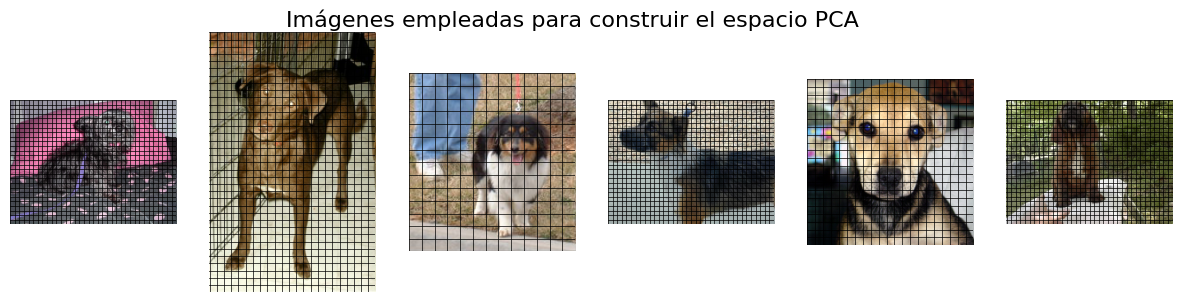

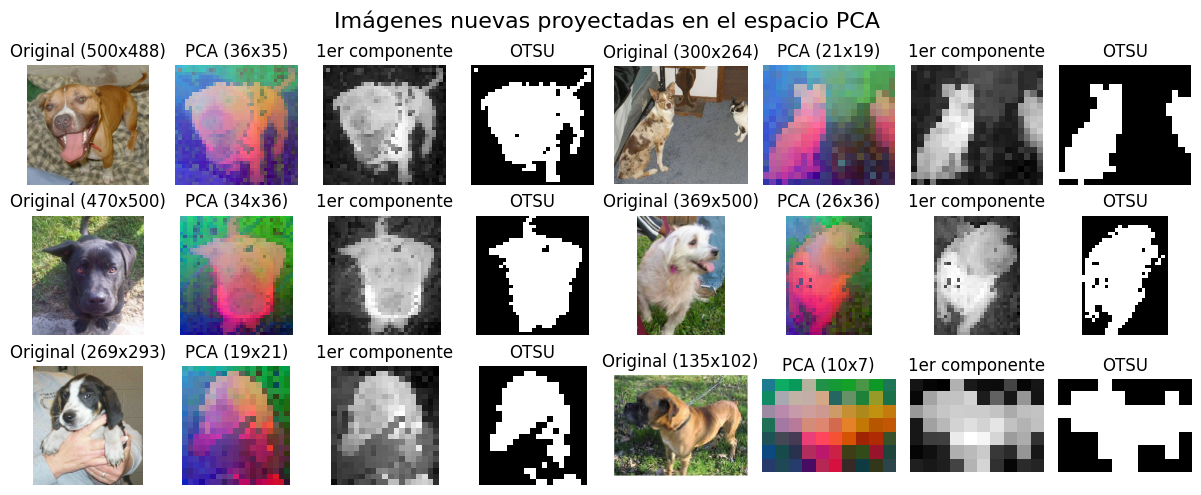

In [6]:
# Extraemos los patch tokens de las primeras imágenes de perros
num_images_PCA = 6
first_dogs = [ Image.open(p) for p in dog_paths[:num_images_PCA] ]
patch_tokens = [infer_dinov2(img, dinov2, device)[1] for img in first_dogs]

# Pasamos de una lista de listas de tokens a una lista de tokens, es decir,
# concatenamos todos los tokens en una misma estructura
all_patch_tokens = np.concatenate(patch_tokens, axis=0)
print(f"Vectores para construir el espacio PCA: {all_patch_tokens.shape} de {num_images_PCA} imágenes")

# Creamos el objeto PCA para reducir a 3 componentes (para RGB)
pca = PCA(n_components=3)

# Ajustamos el PCA con TODOS los tokens de parche de las num_images_PCA imágenes
pca.fit(all_patch_tokens)

# Mostramos las imágenes con las que hemos hecho el PCA
fig, axes = plt.subplots(nrows=1, ncols=len(first_dogs), figsize=(15, 5))
fig.suptitle("Imágenes empleadas para construir el espacio PCA", fontsize=16, y=0.8)
for ax, img in zip(axes, first_dogs):
    # Añade un grid de 14x14 píxeles
    w, h = img.size
    new_w = round(w / PATCH_SIZE) * PATCH_SIZE
    new_h = round(h / PATCH_SIZE) * PATCH_SIZE
    img = img.resize((new_w, new_h), resample=Image.BICUBIC)
    for x in range(0, w, PATCH_SIZE):
        ax.axvline(x=x, color="black", linestyle="-", linewidth=0.5)
    for y in range(0, h, PATCH_SIZE):
        ax.axhline(y=y, color="black", linestyle="-", linewidth=0.5)
    ax.imshow(img)
    ax.axis("off")

# Ahora tenemos una proyección PCA que para un token de parche de DINOv2, reduce
# su dimensionalidad a un vector de 3 coordenadas en el espacio de los perros
# Vamos a probarlo con imágenes nuevas
num_new_images = 6
more_dogs = [ Image.open(p) for p in dog_paths[num_images_PCA:num_images_PCA+num_new_images] ]
fig = plt.figure(figsize=(12, 5))
fig.suptitle("Imágenes nuevas proyectadas en el espacio PCA", fontsize=16)
for i, image in enumerate(more_dogs):
    # Calculamos sus vectores dino
    _, patch_tokens = infer_dinov2(image, dinov2, device)

    # Proyectamos los parches de esta imagen a su representación en 3 coordenadas
    pca_result = pca.transform(patch_tokens)

    # Normalizamos los resultados del PCA a un rango de 0-1 para poder visualizarlos como colores
    pca_result_normalized = (pca_result - pca_result.min()) / (pca_result.max() - pca_result.min())

    # OJO: Reconstruimos la imagen (DINOv2 devuelve los parches aplanados)
    w, h = image.size
    w_p, h_p = round(w/PATCH_SIZE), round(h/PATCH_SIZE)
    pca_image = pca_result_normalized.reshape(h_p, w_p, 3)

    # Mostramos la imagen original
    ax1 = plt.subplot(3, 8, i*4+1)
    ax1.imshow(image)
    ax1.set_title(f"Original ({w}x{h})")
    ax1.axis("off")
    # Mostramos la imagen PCA
    ax2 = plt.subplot(3, 8, i*4+2)
    ax2.imshow(pca_image)
    ax2.set_title(f"PCA ({w_p}x{h_p})")
    ax2.axis("off")
    # Mostramos el primer componente del PCA
    ax3 = plt.subplot(3, 8, i*4+3)
    pca_component = pca_image[:, :, 0]
    ax3.imshow(pca_component, cmap="gray")
    ax3.set_title(f"1er componente")
    ax3.axis("off")
    # Aplicamos umbralizado OTSU al primer componente
    ax4 = plt.subplot(3, 8, i*4+4)
    _, image_result = cv2.threshold(
      (pca_component*255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    ax4.imshow(image_result, cmap="gray")

    ax4.set_title(f"OTSU")
    ax4.axis("off")

plt.tight_layout()
plt.show()

## 3. Segmentación mediante similitud de parches

En las imágenes de PCA anteriores se observa que los parches que corresponden a los perros tienden a mostrar un color similar, mientras que las zonas de fondo aparecen con un color distinto. Esta diferencia sugiere que podemos separar "forma" (el perro) y "fondo" utilizando únicamente la información contenida en los parches.

A partir de esta idea, vamos a seleccionar manualmente algunos parches de referencia de una imagen: unos que representen al perro y otros al fondo. Con ellos construiremos vectores representativos de cada clase (en este caso, los vectores medios de los *embeddings* seleccionados) y después clasificaremos los parches de una nueva imagen según su similitud con estos modelos.

Este enfoque ofrece una segmentación más robusta que la obtenida al quedarnos únicamente con el primer componente del PCA, ya que el objeto de interés no siempre queda capturado de manera clara en ese primer componente (aunque en nuestro caso con los perros sí pasaba).

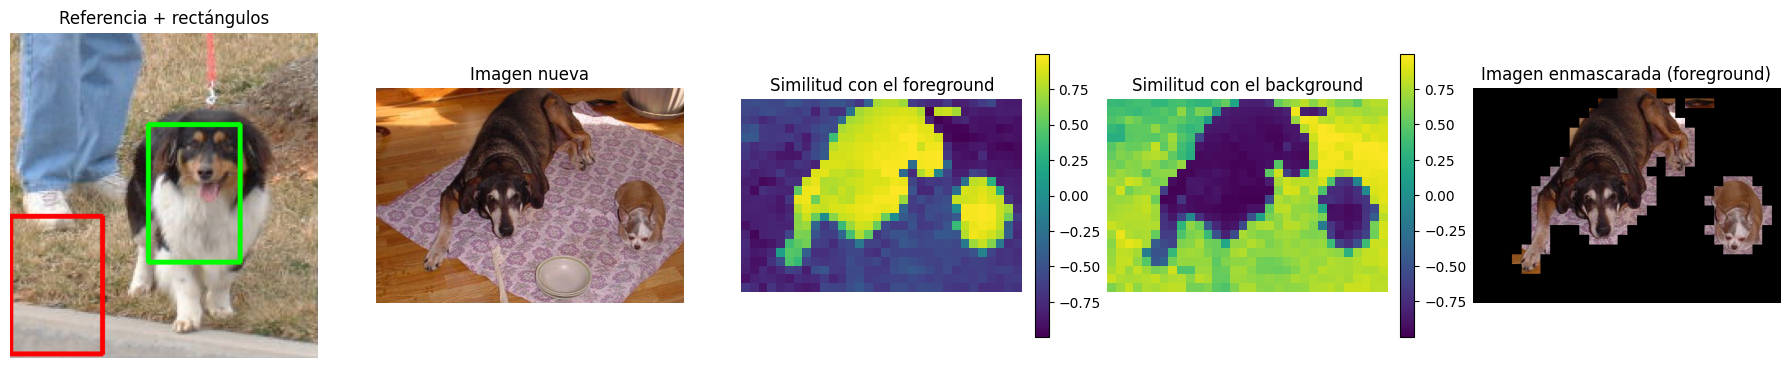

In [7]:
# Extrae los embeddings (patch_tokens) contenidos en el rectángulo `rect`
def get_rect_embeddings(image, patch_tokens, rect, patch_size=PATCH_SIZE):
    # Reshape para transformar de aplanado a la forma de la imagen
    W, H = image.size
    wp, hp = round(W / patch_size), round(H / patch_size)
    D = patch_tokens.shape[-1]
    grid = patch_tokens.reshape(hp, wp, D)

    # Devolvemos solamente los embeddings de dentro del rectángulo
    x1, y1, x2, y2 = rect
    px1, py1, px2, py2 = [ val // PATCH_SIZE for val in rect ]
    region = grid[py1:py2, px1:px2].reshape(-1, D)
    return region

## IMAGEN DE REFERENCIA
image_ref = Image.open(os.path.join(DOGS_DIR, "2.jpg"))
# Seleccionamos dos regiones: una de pixeles del perro y otra con solo de fondo
rect_fg = (84, 56, 140, 140)  # Pixeles de foreground (forma)
rect_bg = (0, 112, 56, 196)   # Pixeles de background (forma)

# Inferimos los embeddings de parches y reducimos dimensión
_, patch_tokens_ref = infer_dinov2(image_ref, dinov2, device)
patch_tokens_ref = pca.transform(patch_tokens_ref)

# Extraemos los embeddings de cada rectángulo y construimos el embedding medio de cada clase
embeddings_fg = get_rect_embeddings(image_ref, patch_tokens_ref, rect_fg)
embeddings_bg = get_rect_embeddings(image_ref, patch_tokens_ref, rect_bg)

# Calculamos el vector medio de los embeddings de forma
# Estos vectores los usamos para representar a cada una de las clases
mean_fg = embeddings_fg.mean(axis=0, keepdims=True)
mean_bg = embeddings_bg.mean(axis=0, keepdims=True)


## IMAGEN NUEVA (cojo esta porque hay dos perros)
image_new = Image.open(os.path.join(DOGS_DIR, "10559.jpg"))

# Inferimos los embeddings de parches y reducimos dimensión
_, patch_tokens_new = infer_dinov2(image_new, dinov2, device)
patch_tokens_new = pca.transform(patch_tokens_new)

# Similaridad de los tokens de la nueva imagen con cada vector modelo
sim_fg = cosine_similarity(patch_tokens_new, mean_fg).ravel()
sim_bg = cosine_similarity(patch_tokens_new, mean_bg).ravel()

# Asignar etiqueta según mayor similitud
labels = np.where(sim_fg >= sim_bg, "forma", "fondo")

## Visualización de los resultados
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

# Imagen de referencia con rectángulos
ref_arr = np.array(image_ref)
cv2.rectangle(ref_arr, rect_fg[:2], rect_fg[2:], (0, 255, 0), 2)
cv2.rectangle(ref_arr, rect_bg[:2], rect_bg[2:], (255, 0, 0), 2)
axes[0].imshow(ref_arr)
axes[0].set_title("Referencia + rectángulos")
axes[0].axis("off")

# Imagen nueva
axes[1].imshow(image_new)
axes[1].set_title("Imagen nueva")
axes[1].axis("off")

# Similitud de la imagen nueva con el foreground
w_new, h_new = image_new.size
wp_new, hp_new = round(w_new / PATCH_SIZE), round(h_new / PATCH_SIZE)
sim_fg_grid = sim_fg.reshape(hp_new, wp_new)
im3 = axes[2].imshow(sim_fg_grid, origin="upper")
axes[2].set_title("Similitud con el foreground")
axes[2].axis("off")
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

# Similitud de la imagen nueva con el foreground
sim_bg_grid = sim_bg.reshape(hp_new, wp_new)
im4 = axes[3].imshow(sim_bg_grid, origin="upper")
axes[3].set_title("Similitud con el background")
axes[3].axis("off")
fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)

# Imagen enmascarada: mostrar solo la parte clasificada como foreground
labels_grid = labels.reshape(hp_new, wp_new)
labels_numeric = (labels_grid == "forma").astype(int)
mask_upscaled = cv2.resize((labels_numeric*255).astype(np.uint8), (w_new, h_new), interpolation=cv2.INTER_NEAREST)
masked_img = cv2.bitwise_and(np.array(image_new), np.array(image_new), mask=mask_upscaled)
axes[4].imshow(masked_img)
axes[4].set_title("Imagen enmascarada (foreground)")
axes[4].axis("off")

plt.tight_layout()
plt.show()

## 3. Matching entre imágenes

A continuación vamos a explorar una idea relacionada. De nuevo, utilizaremos dos imágenes: una como referencia y otra sobre la que buscaremos similitudes. En la imagen de referencia seleccionaremos manualmente algunos parches clave (por ejemplo, un ojo o una pata) y, para cada uno de ellos, buscaremos en la segunda imagen el parche que resulte más parecido según la similitud del coseno entre sus *embeddings*. El objetivo es comprobar si, efectivamente, un parche que contiene el ojo de un perro se corresponde con otro parche similar en la región del ojo del segundo perro.

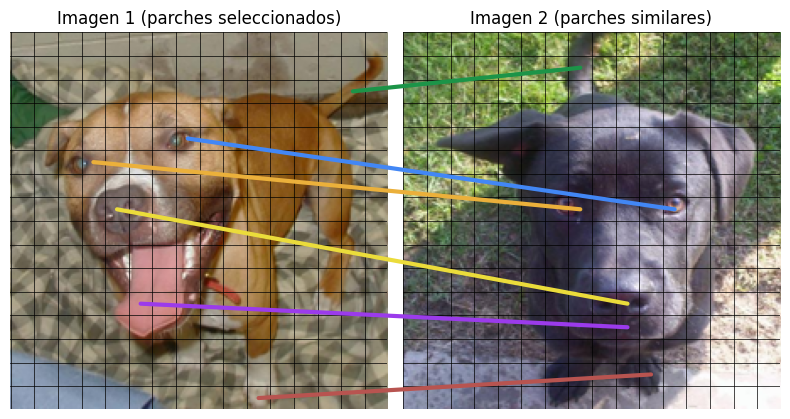

In [8]:
# Activar si se quiere realizar la similitud con los vectores proyectados en el
# espacio PCA. Estos vectores serán contienen menos información, en nuestro
# caso no funciona como se espera.
USE_PCA = False

# Para este apartado, trabajamos con imágenes más pequeñas para que se vea mejor
H, W =  224, 224

# Cogemos dos imágenes y calculamos sus vectores dino
image1 = Image.open(os.path.join(DOGS_DIR, "6.jpg"))
image1 = image1.resize((W, H), resample=Image.BICUBIC)
_, patch_tokens1 = infer_dinov2(image1, dinov2, device)

image2 = Image.open(os.path.join(DOGS_DIR, "8.jpg"))
image2 = image2.resize((W, H), resample=Image.BICUBIC)
_, patch_tokens2 = infer_dinov2(image2, dinov2, device)

# Proyectar si se quiere utilizar PCA
if USE_PCA:
    patch_tokens1 = pca.transform(patch_tokens1)
    patch_tokens2 = pca.transform(patch_tokens2)

# Seleccionamos algunos embeddings en la imagen 1
idx_patch_tokens1 = [46, 71, 83, 116, 181, 250]    # Índice del parche en la imagen aplanada

# Para cada embedding seleccionado, buscamos el embedding más similar de la imagen 2
similarities = []   # Pares de (indice del embedding1, indice del embedding2)
for idx1 in idx_patch_tokens1:
    patch_token1 = patch_tokens1[idx1]
    # Para la similitud, empleamos la similaridad del coseno
    sims = cosine_similarity(patch_token1.reshape(1, -1), patch_tokens2).flatten()

    # Seleccionamos los el embedding más parecido
    top_idx2 = sims.argsort()[-1:][0]

    # Convertimos índices lineales en (row, col)
    similarities.append((idx1, top_idx2))

# Dibujamos los matchings encontrados
fig, ax = plt.subplots(1, 2, figsize=(8, 6))
# Imagen 1
ax[0].imshow(image1)
ax[0].set_title("Imagen 1 (parches seleccionados)")
ax[0].axis("off")
# Imagen 2
ax[1].imshow(image2)
ax[1].set_title("Imagen 2 (parches similares)")
ax[1].axis("off")
# Dibujamos un grid
for x in range(0, W, PATCH_SIZE):
    ax[0].axvline(x=x, color="black", linestyle="-", linewidth=0.5)
    ax[1].axvline(x=x, color="black", linestyle="-", linewidth=0.5)
for y in range(0, H, PATCH_SIZE):
    ax[0].axhline(y=y, color="black", linestyle="-", linewidth=0.5)
    ax[1].axhline(y=y, color="black", linestyle="-", linewidth=0.5)

# Dibujamos líneas rectas para mostrar los matchings de parches
colors = ["#1c9448", "#4287f5", "#EBB03B", "#EBDC3B", "#9B3BEB", "#B85450"]
for (idx1, idx2), c in zip(similarities, colors):
    n = W // PATCH_SIZE   # Parches por fila
    patch_pos1 = (idx1 % n * PATCH_SIZE + PATCH_SIZE / 2,
              idx1 // n * PATCH_SIZE + PATCH_SIZE / 2)
    patch_pos2 = (idx2 % n * PATCH_SIZE + PATCH_SIZE / 2,
              idx2 // n * PATCH_SIZE + PATCH_SIZE / 2)
    con = ConnectionPatch(
        xyA=(patch_pos1[0], patch_pos1[1]), coordsA=ax[0].transData,  # (col, row)
        xyB=(patch_pos2[0], patch_pos2[1]), coordsB=ax[1].transData,
        color=c, lw=3, alpha=1
    )
    fig.add_artist(con)

plt.tight_layout()
plt.show()

**Nota**: Cambiando el valor de la variable `USE_PCA` se observa que los vectores reducidos a tres componentes no son suficientes para hacer el matching entre las partes de los perros. Sin embargo, sí han sido suficientes para determinar la forma de los perros en el apartado anterior.

## 4. Clasificación de perros vs gatos

En este apartado vamos a entrenar un clasificador de imágenes capaz de distinguir entre gatos y perros **a partir de los tokens de clase (CLS)** que nos proporciona DINOv2. Con este fin, entrenaremos un modelo de regresión logística sobre estos. Lo primero que vamos a hacer es preparar las imágenes. Para ello, definimos dos conjuntos de imágenes: uno de *train* para entrenar el clasificador y otro de *test* para probar nuestro modelo con imágenes nuevas.

In [9]:
# Tamaños para los conjuntos de train y test
NUM_TRAIN_DOGS = 25
NUM_TRAIN_CATS = 25
NUM_TEST_DOGS  = 20
NUM_TEST_CATS  = 20

# Cogemos las primeras ocurrencias para train y las siguientes para test
train_paths = dog_paths[:NUM_TRAIN_DOGS] + cat_paths[:NUM_TRAIN_CATS]
test_paths  = dog_paths[NUM_TRAIN_DOGS:NUM_TRAIN_DOGS+NUM_TEST_DOGS] + \
              cat_paths[NUM_TRAIN_CATS:NUM_TRAIN_CATS+NUM_TEST_CATS]

# Etiquetamos los perros como 1 y los gatos como 0
y_train = np.array([1]*NUM_TRAIN_DOGS + [0]*NUM_TRAIN_CATS, dtype=np.int64)
y_test  = np.array([1]*NUM_TEST_DOGS  + [0]*NUM_TEST_CATS,  dtype=np.int64)

print(f"Train: {len(train_paths)} imágenes "
      f"({np.sum(y_train==1)} perros, {np.sum(y_train==0)} gatos)")
print(f"Test:  {len(test_paths)} imágenes "
      f"({np.sum(y_test==1)} perros, {np.sum(y_test==0)} gatos)")

Train: 50 imágenes (25 perros, 25 gatos)
Test:  40 imágenes (20 perros, 20 gatos)


Una vez que tenemos las imágenes preparadas, computamos los tokens de clase CLS para cada una de ellas y construimos el regresor logístico. Lo entrenamos en el conjunto de *train* y lo evaluamos en el conjunto de *test*.

Embeddings extraídos en 7.17s
Modelo de regresión logística entrenado en 0.01s


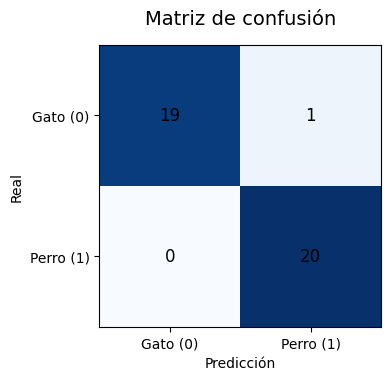

In [10]:
# Extrae los embeddings de DINOv2 a partir de rutas de imágenes
def build_embeddings(paths):
    feats = []
    for p in paths:
        img = Image.open(p)
        v, _ = infer_dinov2(img, dinov2, device)
        feats.append(v.astype("float32"))
    return np.stack(feats, axis=0)

t0 = time.time()
X_train = build_embeddings(train_paths)
X_test  = build_embeddings(test_paths)
print(f"Embeddings extraídos en {time.time()-t0:.2f}s")

# Entrenamos un modelo de regresión logística
t0 = time.time()
clf = make_pipeline(
    StandardScaler(with_mean=True),
    LogisticRegression(max_iter=2000, random_state=42)
)
clf.fit(X_train, y_train)
print(f"Modelo de regresión logística entrenado en {time.time()-t0:.2f}s")

# Evaluamos en el conjunto de test
y_pred = clf.predict(X_test)
cm  = confusion_matrix(y_test, y_pred)

# Mostramos la matriz de confusión con matplotlib
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusión", fontsize=14, pad=15)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Gato (0)", "Perro (1)"])
ax.set_yticklabels(["Gato (0)", "Perro (1)"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
plt.tight_layout()
plt.show()

Por último, mostramos un grid de imágenes de prueba junto con la predicción del modelo. El título de cada imagen se muestra en verde si la predicción es correcta y en rojo si se equivoca.

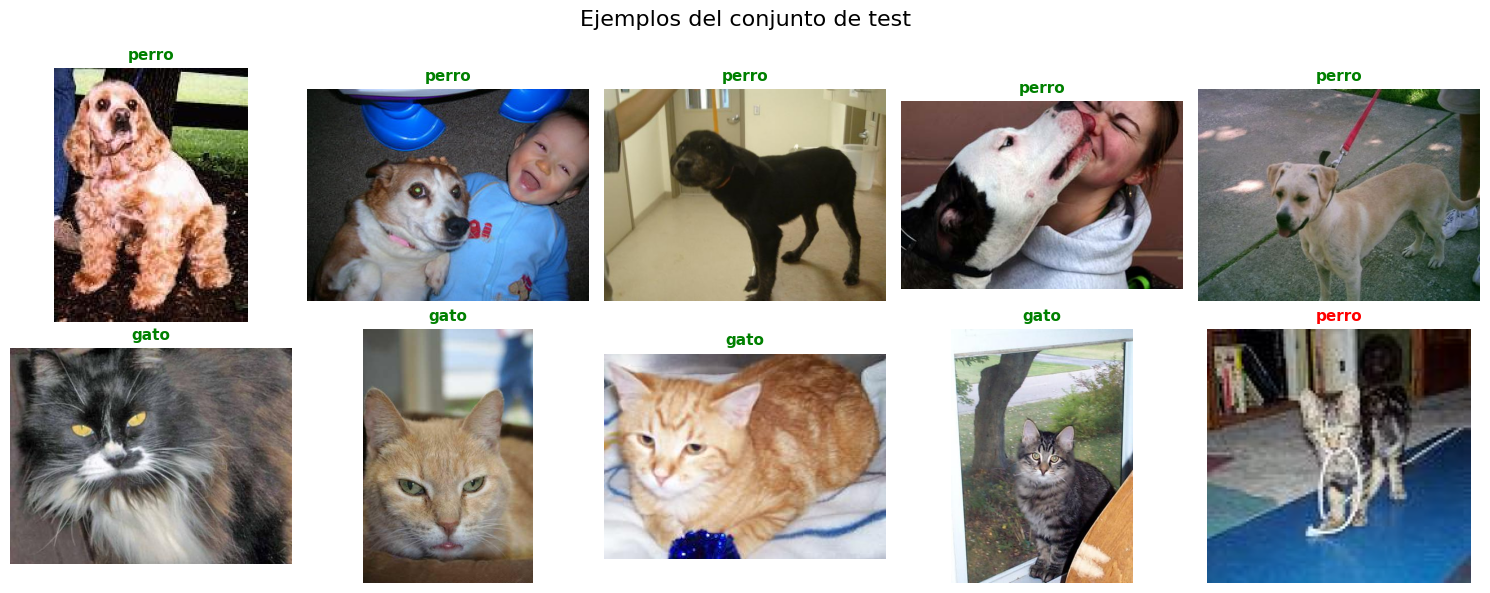

In [11]:
# Visualización de predicciones
def show_predictions_grid(test_paths, y_true, y_pred, title=None, start=0, n_dogs=5, n_cats=5, cols=5):
    # Índices de perros y gatos en el set de test
    dog_idx = [i for i, y in enumerate(y_true) if y == 1]
    cat_idx = [i for i, y in enumerate(y_true) if y == 0]

    # Cogemos los primeros N de cada clase
    chosen_dogs = dog_idx[start:start+n_dogs]
    chosen_cats = cat_idx[start:start+n_cats]
    chosen = chosen_dogs + chosen_cats

    # Grid
    rows = (len(chosen) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    if title: plt.suptitle(title, fontsize=16)
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, chosen):
        img = Image.open(test_paths[idx]).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        pred_label = y_pred[idx]
        true_label = y_true[idx]
        pred_str = "perro" if pred_label == 1 else "gato"
        color = "green" if pred_label == true_label else "red"
        ax.set_title(pred_str, color=color, fontsize=11, fontweight="bold")
    for ax in axes[len(chosen):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


# Mostrar grid de predicciones
show_predictions_grid(test_paths, y_test, y_pred, title="Ejemplos del conjunto de test", start=15, n_dogs=5, n_cats=5, cols=5)

## 5. DINOv2 para la estimación de profundidad

Los *embeddings* que obtenemos con DINOv2 son tan ricos en información visual que se pueden aprovechar en tareas mucho más complejas, como la **estimación de profundidad** en imágenes. Para ello, se entrenan redes neuronales que reciben como entrada los vectores dino y tienen que predecir la profundidad.

Para mostrarlo, en lugar de usar el modelo de DINOv2 que hemos cargado manualmente antes, recurriremos a un [modelo de Hugging Face](https://huggingface.co/facebook/dpt-dinov2-base-kitti), que nos permite acceder a modelos ya preparados y listos para usar, haciendo el proceso mucho más directo y sencillo.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


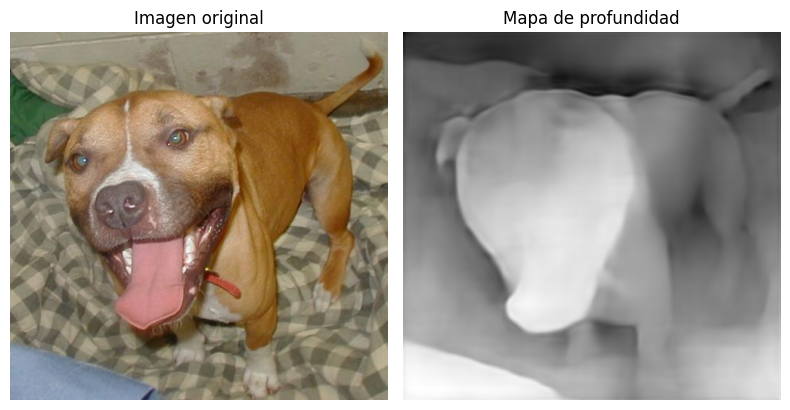

In [12]:
image = Image.open(os.path.join(DOGS_DIR, "6.jpg"))

# Cargamos el modelo desde HuggingFace
image_processor = AutoImageProcessor.from_pretrained("facebook/dpt-dinov2-base-nyu")
model = DPTForDepthEstimation.from_pretrained("facebook/dpt-dinov2-base-nyu")

# Preparar la imagen para el modelo
inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    predicted_depth = outputs.predicted_depth

# Interpolar al tamaño original
prediction = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic",
    align_corners=False,
)
output = prediction.squeeze().cpu().numpy()

# Normalizamos el mapa de profundidad para poder pintarlo
min_value = np.min(output)
max_value = np.max(output)
depth = (output - min_value) / (max_value - min_value)

# Mostramos los resultados
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
# Imagen original
axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("Imagen original")
# Mapa de profundidad
axes[1].imshow(depth, cmap="gray_r")
axes[1].axis("off")
axes[1].set_title("Mapa de profundidad")

plt.tight_layout()
plt.show()

## Enlaces de interés

* [Página Oficial de DINOv2](https://dinov2.metademolab.com/). Donde se puede acceder al artículo y a algunas demos.
* [GitHub Oficial de DINOv2](https://github.com/facebookresearch/dinov2). Puesta en marcha e interesante el directorio de *notebooks* con más ejemplos de código.